In [1]:
#attach google drive
from google.colab import drive
drive.mount('/content/drive/')

Drive already mounted at /content/drive/; to attempt to forcibly remount, call drive.mount("/content/drive/", force_remount=True).


In [2]:
# -*- coding: utf-8 -*-
"""
Mobile Phone Price Prediction
"""

# ===============================
# Imports
# ===============================
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [3]:
# ===============================
# Global Plot Styling
# ===============================
sns.set_theme(style="whitegrid")
plt.rcParams.update({
    "figure.figsize": (9, 5.5),
    "axes.titleweight": "bold",
    "axes.titlesize": 14,
    "axes.labelsize": 12,
    "font.size": 11
})

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

In [4]:
# ===============================
# Load Dataset
# ===============================
data_path = "/content/drive/MyDrive/Mobile_Phone_Prices_Based_Dataset/Mobile_Phone_Prices_Based_Dataset.csv"
df = pd.read_csv(data_path)

In [5]:
print("Shape:", df.shape)

Shape: (1359, 21)


In [6]:
display(df.head())

,name,brand,model,battery_capacity_mAh,screen_size_inches,touch_screen,resolution_x,resolution_y,processor,RAM_MB,...,rear_camera,front_camera,operating_system,Wi_Fi,Bluetooth,GPS,number_of_SIMs,3G,4G_LTE,price
0,OnePlus 7T Pro McLaren Edition,OnePlus,7T Pro McLaren Edition,4085,6.67,Yes,1440,3120,8,12000,...,48.0,16.0,Android,Yes,Yes,Yes,2,Yes,Yes,58998
1,Realme X2 Pro,Realme,X2 Pro,4000,6.50,Yes,1080,2400,8,6000,...,64.0,16.0,Android,Yes,Yes,Yes,2,Yes,Yes,27999
2,iPhone 11 Pro Max,Apple,iPhone 11 Pro Max,3969,6.50,Yes,1242,2688,6,4000,...,12.0,12.0,iOS,Yes,Yes,Yes,2,Yes,Yes,106900
3,iPhone 11,Apple,iPhone 11,3110,6.10,Yes,828,1792,6,4000,...,12.0,12.0,iOS,Yes,Yes,Yes,2,Yes,Yes,62900
4,LG G8X ThinQ,LG,G8X ThinQ,4000,6.40,Yes,1080,2340,8,6000,...,12.0,32.0,Android,Yes,Yes,Yes,1,No,No,49990


In [7]:
# ===============================
# Basic Cleaning
# ===============================
df.drop_duplicates(inplace=True)
df.columns = df.columns.str.strip().str.lower()

In [8]:
# ===============================
# Handle Missing Values
# ===============================
num_cols = df.select_dtypes(include=np.number).columns
cat_cols = df.select_dtypes(include="object").columns

for col in num_cols:
    df[col] = df[col].fillna(df[col].median())

for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

In [9]:
# ===============================
# Convert Yes/No → 0/1
# ===============================
binary_cols = [
    "touch_screen", "wi_fi", "bluetooth",
    "gps", "3g", "4g_lte"
]

for col in binary_cols:
    if col in df.columns:
        df[col] = df[col].replace({
            "Yes": 1, "No": 0,
            "yes": 1, "no": 0
        })

In [10]:
# =========================================================
# FEATURE ENGINEERING
# =========================================================
def safe_divide(a, b):
    return np.where(b == 0, 0, a / b)

#  uses target — keep for EDA but drop before training
if {"price", "ram"}.issubset(df.columns):
    df["price_per_ram"] = safe_divide(df["price"], df["ram"])

if {"storage", "ram"}.issubset(df.columns):
    df["storage_ram_ratio"] = safe_divide(df["storage"], df["ram"])

if {"battery_capacity_mah", "screen_size_inches"}.issubset(df.columns):
    df["battery_per_screen"] = safe_divide(
        df["battery_capacity_mah"],
        df["screen_size_inches"]
    )

if {"resolution_x", "resolution_y", "screen_size_inches"}.issubset(df.columns):
    df["pixels_per_inch"] = safe_divide(
        np.sqrt(df["resolution_x"]**2 + df["resolution_y"]**2),
        df["screen_size_inches"]
    )

if {"rear_camera", "front_camera"}.issubset(df.columns):
    df["total_camera_pixels"] = df["rear_camera"] + df["front_camera"]

print("\n✅ Feature engineering completed.")


✅ Feature engineering completed.


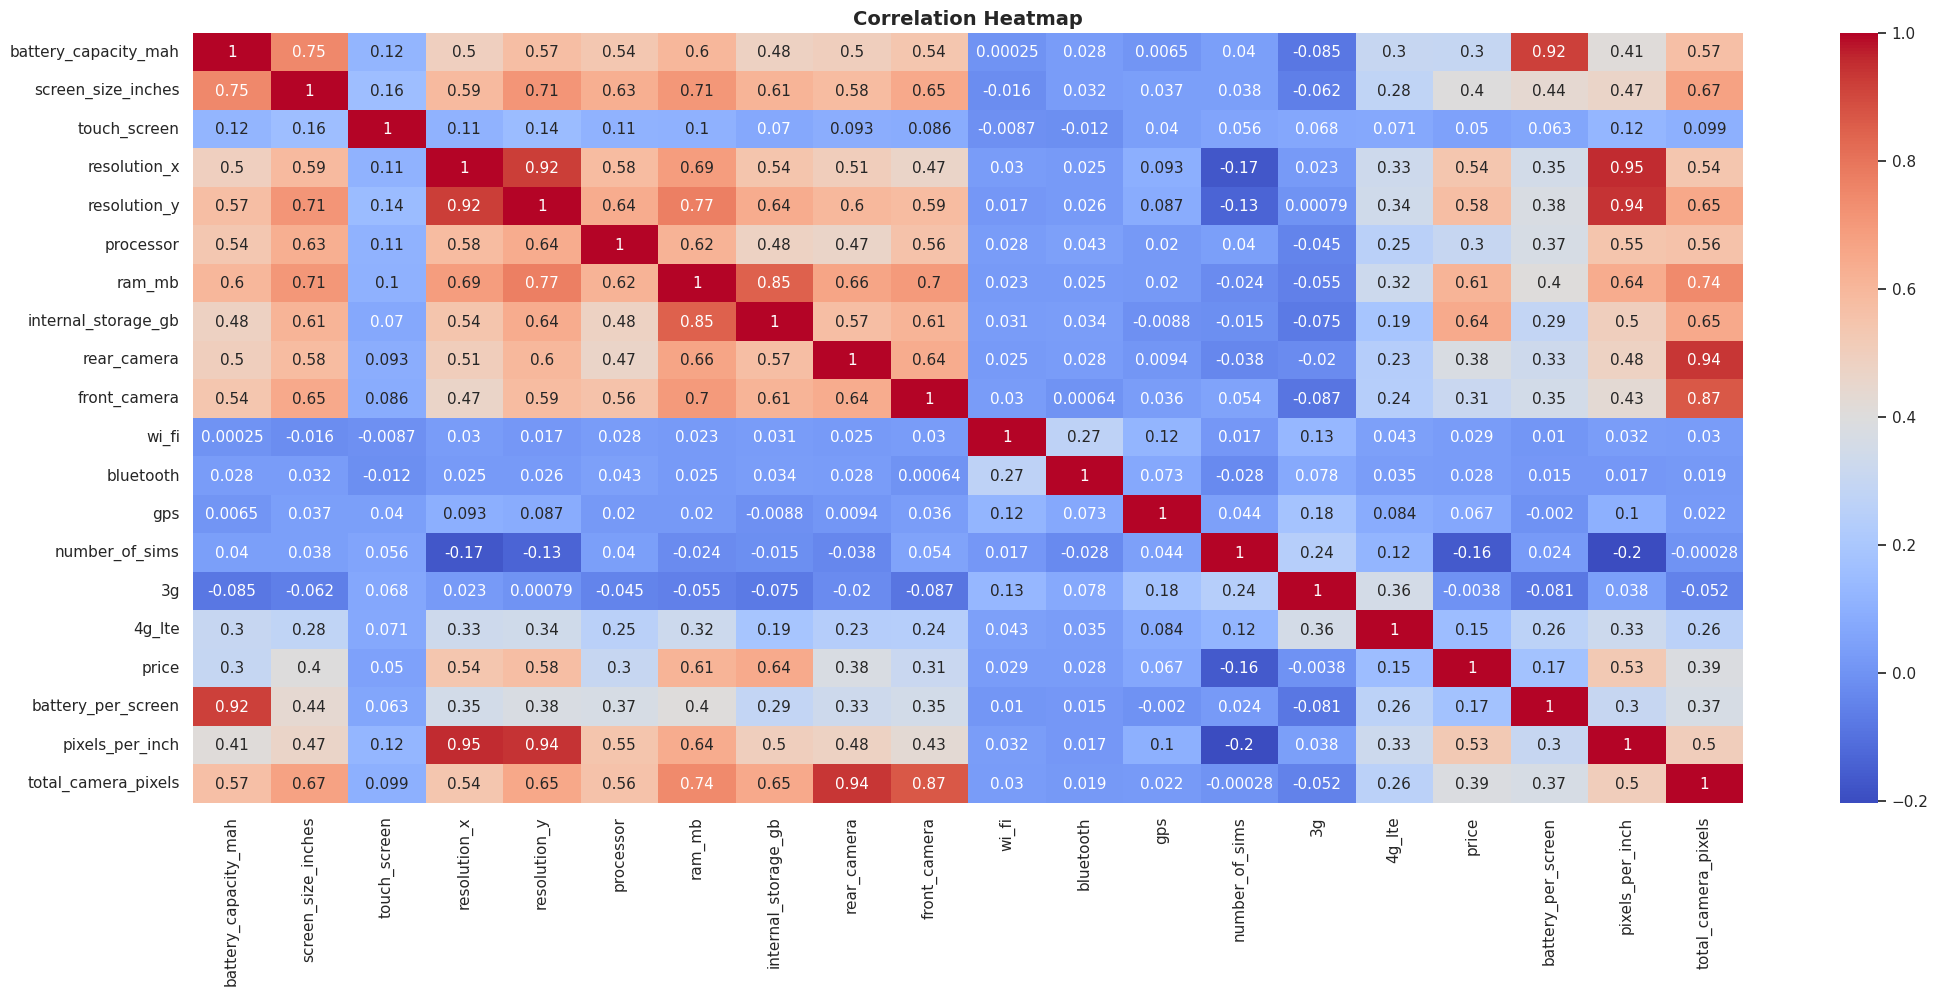

In [11]:
# =========================================================
# Correlation Heatmap (Numeric Features)
# =========================================================
numeric_data = df.select_dtypes(include=[np.number])

plt.figure(figsize=(25, 10))
sns.heatmap(numeric_data.corr(), cmap='coolwarm', annot=True)
plt.title("Correlation Heatmap")
plt.show()


In [12]:
# =========================================================
# HELPER — Funtion For Scatter
# =========================================================
def scatter(df, x_col, y_col="price", color="#2563eb"):
    plt.figure()

    sns.scatterplot(
        data=df,
        x=x_col,
        y=y_col,
        alpha=0.6,
        s=55,
        edgecolor="white",
        linewidth=0.4,
        color=color
    )

    sns.regplot(
        data=df,
        x=x_col,
        y=y_col,
        scatter=False,
        lowess=True,
        color="#dc2626",
        line_kws={"linewidth": 2}
    )

    plt.title(f"{x_col.replace('_',' ').title()} vs Mobile Price")
    plt.xlabel(x_col.replace("_", " ").title())
    plt.ylabel("Mobile Price")
    plt.tight_layout()
    plt.show()

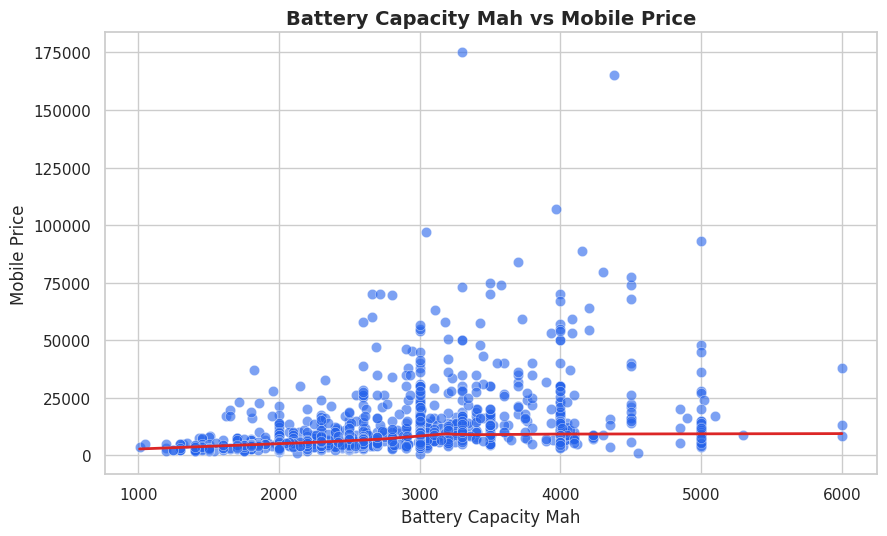

In [13]:
# ===============================
# EDA Plots
# ===============================

if "battery_capacity_mah" in df.columns:
    scatter(df, "battery_capacity_mah")

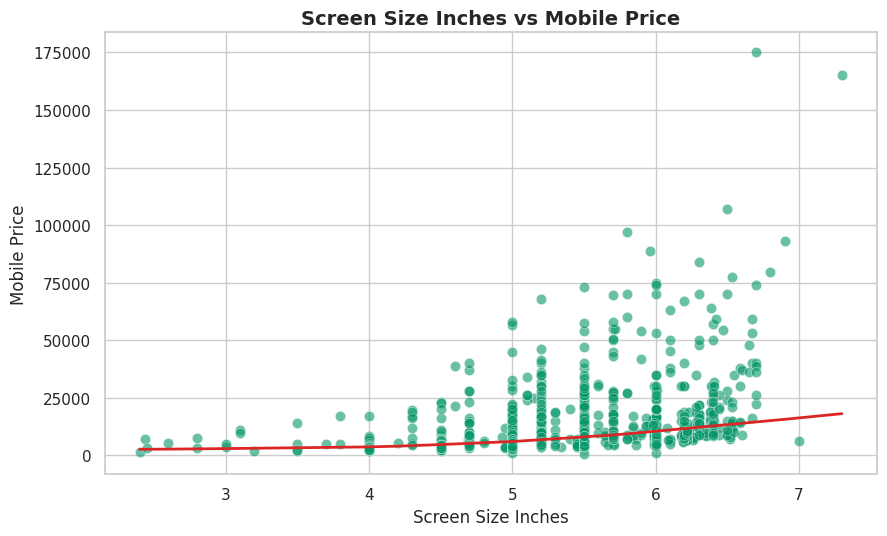

In [14]:
if "screen_size_inches" in df.columns:
    scatter(df, "screen_size_inches", color="#059669")

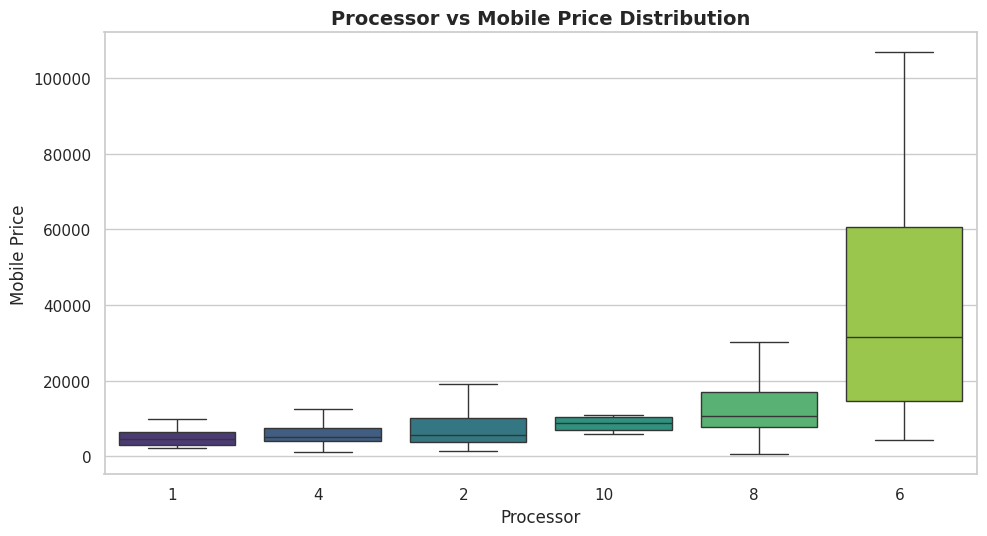

In [15]:
# Processor vs Price
if "processor" in df.columns:
    plt.figure(figsize=(10, 5.5))

    processor_order = (
        df.groupby("processor")["price"]
        .median()
        .sort_values()
        .index
    )

    sns.boxplot(
        data=df,
        x="processor",
        y="price",
        order=processor_order,
        palette="viridis",
        linewidth=1,
        showfliers=False
    )

    plt.xticks(rotation=0, ha="right")
    plt.title("Processor vs Mobile Price Distribution")
    plt.xlabel("Processor")
    plt.ylabel("Mobile Price")
    plt.tight_layout()
    plt.show()

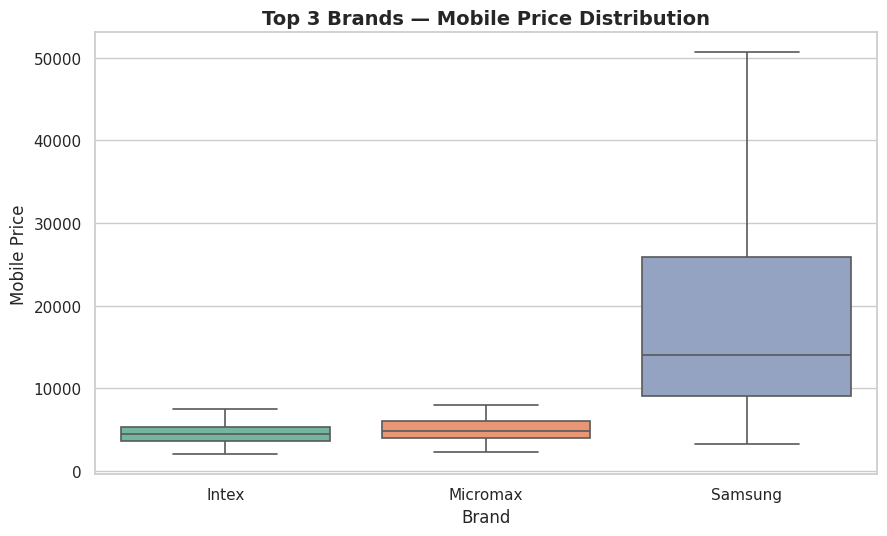

In [16]:
# Top-3 Brand Plot
if "brand" in df.columns:
    plt.figure(figsize=(9, 5.5))

    top_brands = df["brand"].value_counts().nlargest(3).index
    df_top = df[df["brand"].isin(top_brands)].copy()

    brand_order = (
        df_top.groupby("brand")["price"]
        .median()
        .sort_values()
        .index
    )

    sns.boxplot(
        data=df_top,
        x="brand",
        y="price",
        order=brand_order,
        palette="Set2",
        linewidth=1.2,
        showfliers=False
    )

    plt.title("Top 3 Brands — Mobile Price Distribution")
    plt.xlabel("Brand")
    plt.ylabel("Mobile Price")
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()

In [17]:
# =========================================================
# 🤖 MODEL TRAINING — RANDOM FOREST
# =========================================================
print("\n🚀 Preparing data for training...")

# Drop identifiers
for col in ["name", "model"]:
    if col in df.columns:
        df.drop(columns=col, inplace=True)


🚀 Preparing data for training...


In [18]:
# Remove leakage feature
if "price_per_ram" in df.columns:
    df_model = df.drop(columns=["price_per_ram"]).copy()
else:
    df_model = df.copy()

In [19]:
# One-hot encoding
cat_cols_model = df_model.select_dtypes(include="object").columns.tolist()
df_model = pd.get_dummies(df_model, columns=cat_cols_model, drop_first=True)

In [20]:
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split

# ===============================
# Encode Categorical Variables
# ===============================
le = LabelEncoder()

cat_cols = df_model.select_dtypes(include='object').columns

for col in cat_cols:
    df_model[col] = le.fit_transform(df_model[col])

# ===============================
# Split Features and Target
# ===============================
X = df_model.drop("price", axis=1)
y = df_model["price"]

# ===============================
# Feature Scaling
# ===============================
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print(X_scaled)


# ===============================
# Train Test Split
# ===============================
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y,
    test_size=0.2,
    random_state=RANDOM_STATE
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)


[[ 1.31300992  2.0543446   0.1125507  ... -0.04703604 -0.11907604
  -0.1125507 ]
 [ 1.215666    1.80103274  0.1125507  ... -0.04703604 -0.11907604
  -0.1125507 ]
 [ 1.1801641   1.80103274  0.1125507  ... -0.04703604 -0.11907604
   8.88488472]
 ...
 [-1.41834596 -1.17910679  0.1125507  ... -0.04703604 -0.11907604
  -0.1125507 ]
 [-1.93369613 -1.92414167  0.1125507  ... -0.04703604 -0.11907604
  -0.1125507 ]
 [-0.9029958  -0.43407191  0.1125507  ... -0.04703604 -0.11907604
  -0.1125507 ]]
Train shape: (1087, 100)
Test shape: (272, 100)


In [21]:
# Split
# X = df_model.drop("price", axis=1)
# y = df_model["price"]

# X_train, X_test, y_train, y_test = train_test_split(
#     X, y,
#     test_size=0.2,
#     random_state=RANDOM_STATE
# )

# print("Train shape:", X_train.shape)
# print("Test shape:", X_test.shape)

In [22]:
# Train model
print("\n🌲 Training Random Forest...")

rf_model = RandomForestRegressor(
    n_estimators=300,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)


🌲 Training Random Forest...


RandomForestRegressor(n_estimators=300, n_jobs=-1, random_state=42)

In [23]:
# =========================================================
# Evaluation
# =========================================================
y_pred = rf_model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("\n📊 MODEL PERFORMANCE")
print(f"MAE  : {mae:.2f}")
print(f"RMSE : {rmse:.2f}")
print(f"R²   : {r2:.4f}")


📊 MODEL PERFORMANCE
MAE  : 3686.20
RMSE : 9413.63
R²   : 0.6638


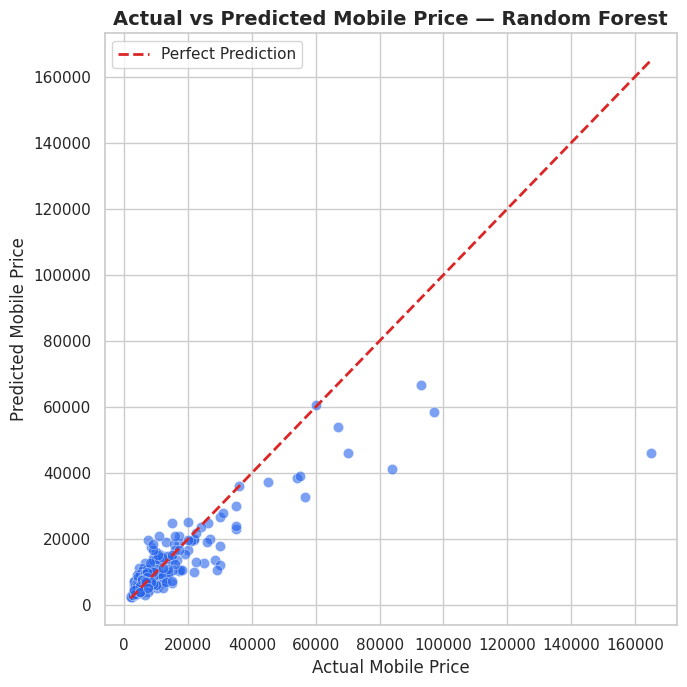

In [24]:
# =========================================================
# Actual vs Predicted Plot
# =========================================================
plt.figure(figsize=(7, 7))

sns.scatterplot(
    x=y_test,
    y=y_pred,
    alpha=0.6,
    s=55,
    edgecolor="white",
    linewidth=0.4,
    color="#2563eb"
)

min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())

plt.plot(
    [min_val, max_val],
    [min_val, max_val],
    color="#dc2626",
    linewidth=2,
    linestyle="--",
    label="Perfect Prediction"
)

plt.xlabel("Actual Mobile Price")
plt.ylabel("Predicted Mobile Price")
plt.title("Actual vs Predicted Mobile Price — Random Forest")
plt.legend()
plt.tight_layout()
plt.show()


📊 E-Pop Plot — Random Forest


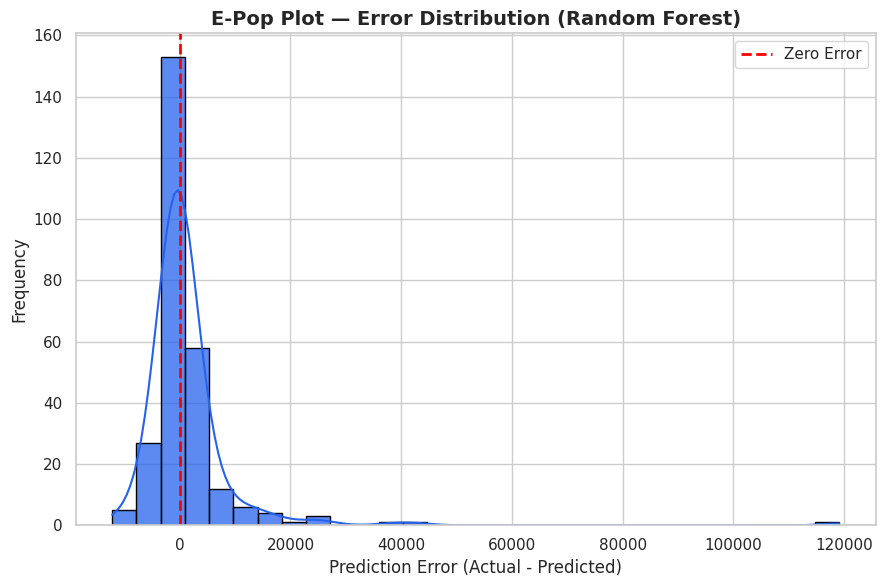

Mean Error: 1250.4569
Std Dev    : 9347.4047


In [25]:
print("\n📊 E-Pop Plot — Random Forest")

errors_rf = y_test - y_pred

plt.figure(figsize=(9, 6))

sns.histplot(
    errors_rf,
    bins=30,
    kde=True,
    color="#2563eb",
    edgecolor="black",
    alpha=0.75
)

plt.axvline(0, color="red", linestyle="--", linewidth=2, label="Zero Error")

plt.title("E-Pop Plot — Error Distribution (Random Forest)", fontsize=14, weight="bold")
plt.xlabel("Prediction Error (Actual - Predicted)")
plt.ylabel("Frequency")
plt.legend()

plt.tight_layout()
plt.show()

print(f"Mean Error: {errors_rf.mean():.4f}")
print(f"Std Dev    : {errors_rf.std():.4f}")

In [26]:
# =========================================================
# 🌿 MODEL TRAINING — GRADIENT BOOSTING
# =========================================================

print("\n🌿 Training Gradient Boosting Regressor...")

gb_model = GradientBoostingRegressor(
n_estimators=300,
learning_rate=0.05,
max_depth=4,
random_state=RANDOM_STATE
)

gb_model.fit(X_train, y_train)


🌿 Training Gradient Boosting Regressor...


GradientBoostingRegressor(learning_rate=0.05, max_depth=4, n_estimators=300,
                          random_state=42)

In [27]:
# =========================================================
# Evaluation — Gradient Boosting
# =========================================================

y_pred_gb = gb_model.predict(X_test)

mae_gb = mean_absolute_error(y_test, y_pred_gb)
rmse_gb = np.sqrt(mean_squared_error(y_test, y_pred_gb))
r2_gb = r2_score(y_test, y_pred_gb)

print("\n📊 GRADIENT BOOSTING PERFORMANCE")
print(f"MAE : {mae_gb:.2f}")
print(f"RMSE : {rmse_gb:.2f}")
print(f"R² : {r2_gb:.4f}")


📊 GRADIENT BOOSTING PERFORMANCE
MAE : 3743.75
RMSE : 9449.12
R² : 0.6613


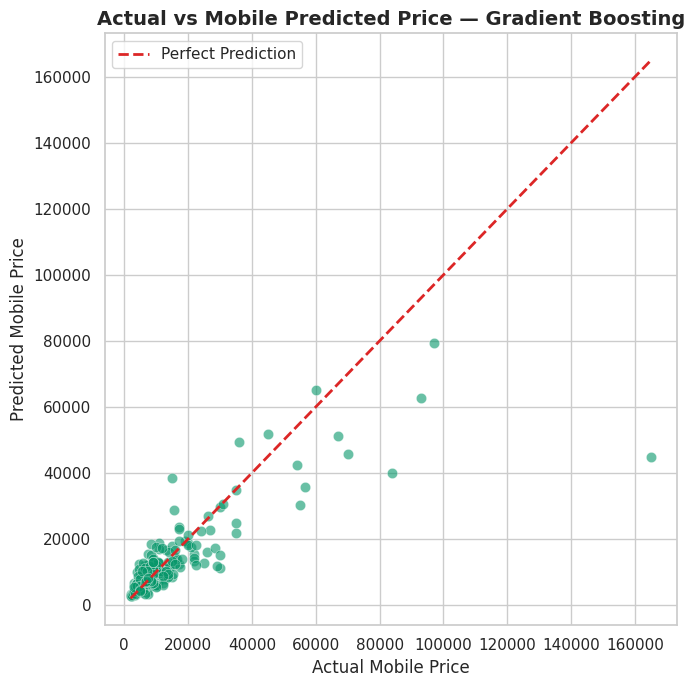

In [28]:
# =========================================================
# Actual vs Predicted Plot — Gradient Boosting
# =========================================================

plt.figure(figsize=(7, 7))

sns.scatterplot(
x=y_test,
y=y_pred_gb,
alpha=0.6,
s=55,
edgecolor="white",
linewidth=0.4,
color="#059669"
)

min_val = min(y_test.min(), y_pred_gb.min())
max_val = max(y_test.max(), y_pred_gb.max())

plt.plot(
[min_val, max_val],
[min_val, max_val],
color="#dc2626",
linewidth=2,
linestyle="--",
label="Perfect Prediction"
)

plt.xlabel("Actual Mobile Price")
plt.ylabel("Predicted Mobile Price")
plt.title("Actual vs Mobile Predicted Price — Gradient Boosting")
plt.legend()
plt.tight_layout()
plt.show()


📊 E-Pop Plot — Gradient Boosting


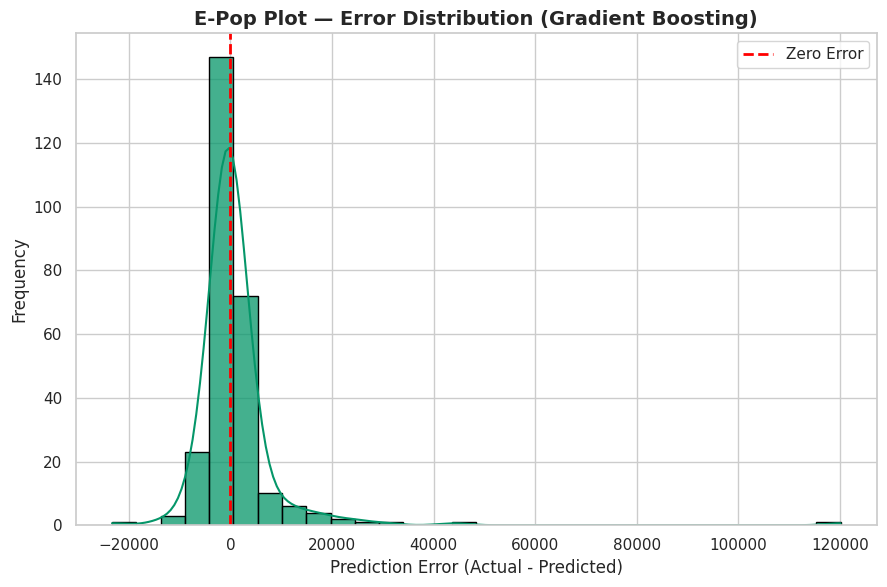

Mean Error: 972.0394
Std Dev    : 9416.3146


In [29]:
print("\n📊 E-Pop Plot — Gradient Boosting")

errors_gb = y_test - y_pred_gb

plt.figure(figsize=(9, 6))

sns.histplot(
    errors_gb,
    bins=30,
    kde=True,
    color="#059669",
    edgecolor="black",
    alpha=0.75
)

plt.axvline(0, color="red", linestyle="--", linewidth=2, label="Zero Error")

plt.title("E-Pop Plot — Error Distribution (Gradient Boosting)", fontsize=14, weight="bold")
plt.xlabel("Prediction Error (Actual - Predicted)")
plt.ylabel("Frequency")
plt.legend()

plt.tight_layout()
plt.show()

print(f"Mean Error: {errors_gb.mean():.4f}")
print(f"Std Dev    : {errors_gb.std():.4f}")

In [30]:
# =========================================================
# 🚀 MODEL TRAINING — XGBOOST REGRESSOR
# =========================================================
print("\n🚀 Training XGBoost Regressor...")

xgb_model = XGBRegressor(
    n_estimators=400,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    objective="reg:squarederror",
    verbosity=0
)

xgb_model.fit(X_train, y_train)


🚀 Training XGBoost Regressor...


XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=5,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=400,
             n_jobs=-1, num_parallel_tree=None, ...)

In [31]:
# =========================================================
# Evaluation — XGBoost
# =========================================================
y_pred_xgb = xgb_model.predict(X_test)

mae_xgb = mean_absolute_error(y_test, y_pred_xgb)
rmse_xgb = np.sqrt(mean_squared_error(y_test, y_pred_xgb))
r2_xgb = r2_score(y_test, y_pred_xgb)

print("\n📊 XGBOOST PERFORMANCE")
print(f"MAE  : {mae_xgb:.2f}")
print(f"RMSE : {rmse_xgb:.2f}")
print(f"R²   : {r2_xgb:.4f}")


📊 XGBOOST PERFORMANCE
MAE  : 3450.46
RMSE : 9297.31
R²   : 0.6721


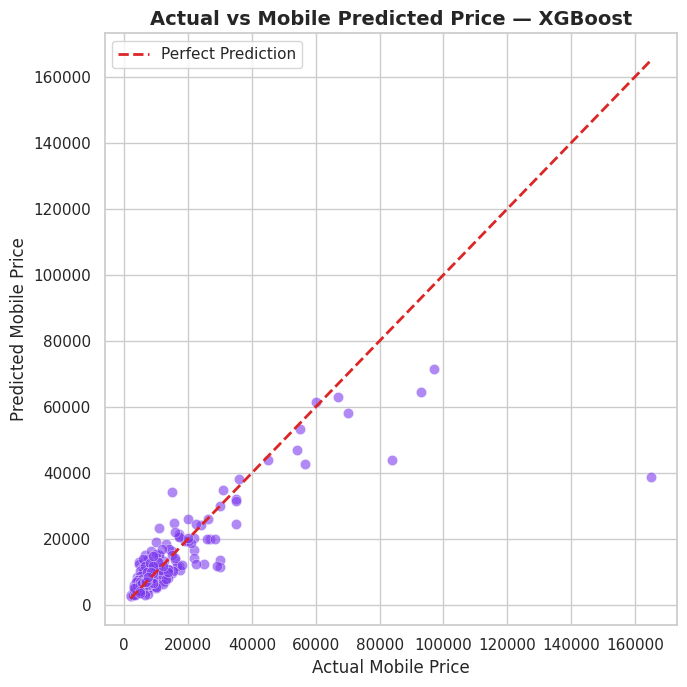

In [32]:
# =========================================================
# Actual vs Predicted Plot — XGBoost
# =========================================================
plt.figure(figsize=(7, 7))

sns.scatterplot(
    x=y_test,
    y=y_pred_xgb,
    alpha=0.6,
    s=55,
    edgecolor="white",
    linewidth=0.4,
    color="#7c3aed"
)

min_val = min(y_test.min(), y_pred_xgb.min())
max_val = max(y_test.max(), y_pred_xgb.max())

plt.plot(
    [min_val, max_val],
    [min_val, max_val],
    color="#dc2626",
    linewidth=2,
    linestyle="--",
    label="Perfect Prediction"
)

plt.xlabel("Actual Mobile Price")
plt.ylabel("Predicted Mobile Price")
plt.title("Actual vs Mobile Predicted Price — XGBoost")
plt.legend()
plt.tight_layout()
plt.show()


📊 E-Pop Plot — XGBoost


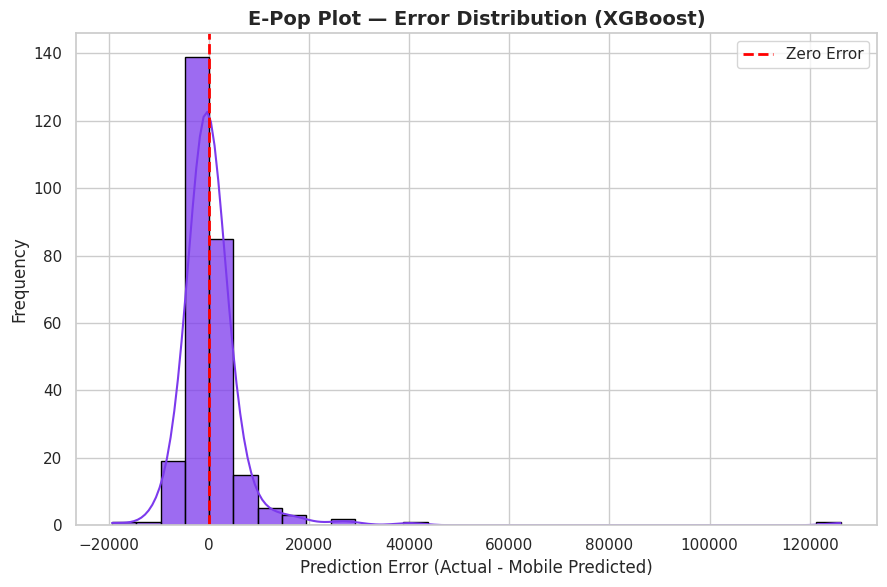

Mean Error: 725.5916
Std Dev    : 9286.0418


In [33]:
print("\n📊 E-Pop Plot — XGBoost")

errors_xgb = y_test - y_pred_xgb

plt.figure(figsize=(9, 6))

sns.histplot(
    errors_xgb,
    bins=30,
    kde=True,
    color="#7c3aed",
    edgecolor="black",
    alpha=0.75
)

plt.axvline(0, color="red", linestyle="--", linewidth=2, label="Zero Error")

plt.title("E-Pop Plot — Error Distribution (XGBoost)", fontsize=14, weight="bold")
plt.xlabel("Prediction Error (Actual - Mobile Predicted)")
plt.ylabel("Frequency")
plt.legend()

plt.tight_layout()
plt.show()

print(f"Mean Error: {errors_xgb.mean():.4f}")
print(f"Std Dev    : {errors_xgb.std():.4f}")


📊 Plotting MAE & RMSE Comparison...


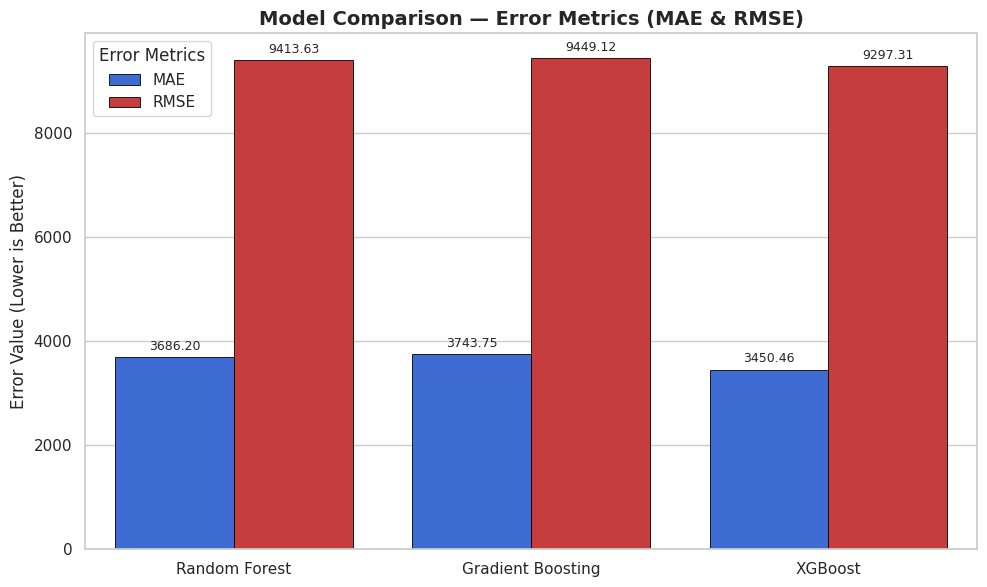

In [34]:
# =========================================================
# 📊 Error Metrics Comparison (MAE & RMSE)
# =========================================================
print("\n📊 Plotting MAE & RMSE Comparison...")

error_df = pd.DataFrame({
    "Model": ["Random Forest", "Gradient Boosting", "XGBoost"],
    "MAE": [mae, mae_gb, mae_xgb],
    "RMSE": [rmse, rmse_gb, rmse_xgb]
})

error_melted = error_df.melt(
    id_vars="Model",
    var_name="Metric",
    value_name="Value"
)

plt.figure(figsize=(10, 6))

ax = sns.barplot(
    data=error_melted,
    x="Model",
    y="Value",
    hue="Metric",
    palette=["#2563eb", "#dc2626"],
    edgecolor="black",
    linewidth=0.6
)

for container in ax.containers:
    ax.bar_label(container, fmt="%.2f", padding=3, fontsize=9)

plt.title("Model Comparison — Error Metrics (MAE & RMSE)", fontsize=14, weight="bold")
plt.ylabel("Error Value (Lower is Better)")
plt.xlabel("")
plt.xticks(rotation=0)
plt.legend(title="Error Metrics")
plt.tight_layout()
plt.show()


📈 Plotting R² Comparison...


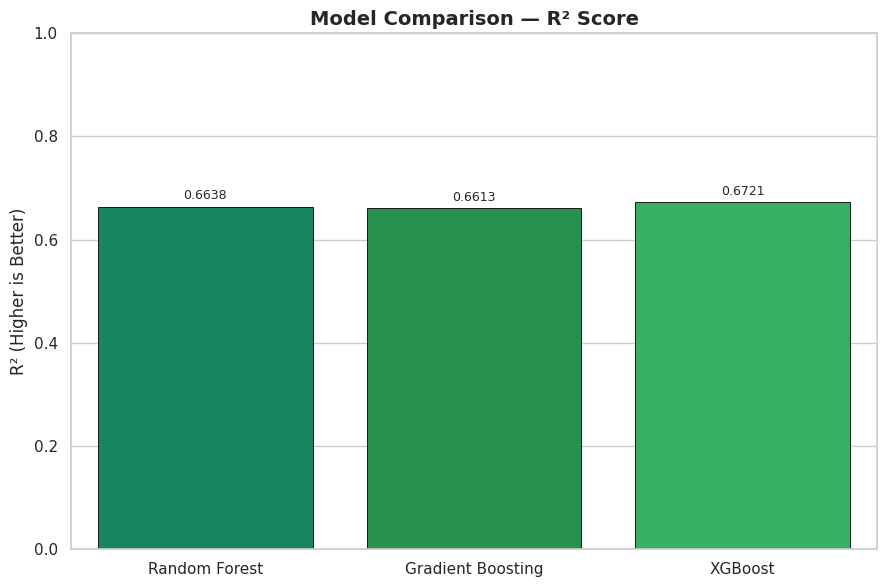

In [35]:
# =========================================================
# 📈 R² Comparison (Explained Variance)
# =========================================================
print("\n📈 Plotting R² Comparison...")

r2_df = pd.DataFrame({
    "Model": ["Random Forest", "Gradient Boosting", "XGBoost"],
    "R²": [r2, r2_gb, r2_xgb]
})

plt.figure(figsize=(9, 6))

ax = sns.barplot(
    data=r2_df,
    x="Model",
    y="R²",
    palette=["#059669", "#16a34a", "#22c55e"],
    edgecolor="black",
    linewidth=0.6
)

for container in ax.containers:
    ax.bar_label(container, fmt="%.4f", padding=3, fontsize=9)

plt.title("Model Comparison — R² Score", fontsize=14, weight="bold")
plt.ylabel("R² (Higher is Better)")
plt.xlabel("")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [36]:
# =========================================================
# 🏆 Determine Best Model Based on Evaluation Metrics
# =========================================================
print("\n🏆 Determining Best Model...")

# Create dictionary of metrics
metrics = {
    "Random Forest": {"MAE": mae, "RMSE": rmse, "R2": r2},
    "Gradient Boosting": {"MAE": mae_gb, "RMSE": rmse_gb, "R2": r2_gb},
    "XGBoost": {"MAE": mae_xgb, "RMSE": rmse_xgb, "R2": r2_xgb}
}

# Convert to DataFrame
comparison_df = pd.DataFrame(metrics).T
comparison_df.index.name = "Model"

# Identify best per metric
best_mae_model = comparison_df["MAE"].idxmin()
best_rmse_model = comparison_df["RMSE"].idxmin()
best_r2_model = comparison_df["R2"].idxmax()

# Compute overall score: count of "best metric wins"
comparison_df["Best_count"] = 0
comparison_df.loc[best_mae_model, "Best_count"] += 1
comparison_df.loc[best_rmse_model, "Best_count"] += 1
comparison_df.loc[best_r2_model, "Best_count"] += 1

# Overall best model = most wins
overall_best_model = comparison_df["Best_count"].idxmax()

# Display
print("\n📊 Model Performance Comparison:")
print(comparison_df[["MAE", "RMSE", "R2", "Best_count"]])

print(f"\n🏆 Best Model Overall: {overall_best_model}")
print(f"Best MAE Model     : {best_mae_model}")
print(f"Best RMSE Model    : {best_rmse_model}")
print(f"Best R² Model      : {best_r2_model}")


🏆 Determining Best Model...

📊 Model Performance Comparison:
                           MAE         RMSE        R2  Best_count
Model                                                            
Random Forest      3686.201649  9413.627804  0.663810           0
Gradient Boosting  3743.750233  9449.119467  0.661270           0
XGBoost            3450.456543  9297.312730  0.672067           3

🏆 Best Model Overall: XGBoost
Best MAE Model     : XGBoost
Best RMSE Model    : XGBoost
Best R² Model      : XGBoost


**Random Forest Hyperparameter Optimization**

In [37]:
print("\n" + "=" * 60)
print("RANDOM FOREST HYPERPARAMETER OPTIMIZATION")
print("=" * 60)

rf = RandomForestRegressor(random_state=42)

rf_params = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
    'max_features': ['sqrt', 'log2']
}

rf_grid = RandomizedSearchCV(
    estimator=rf,
    param_distributions=rf_params,
    n_iter=20,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    random_state=42,
    verbose=1
)

rf_grid.fit(X_train, y_train)

print("Best Parameters:", rf_grid.best_params_)
print("Best Score:", rf_grid.best_score_)

best_rf = rf_grid.best_estimator_


RANDOM FOREST HYPERPARAMETER OPTIMIZATION
Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best Parameters: {'n_estimators': 200, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': 20}
Best Score: 0.5780161240943517


**Gradient Boosting Hyperparameter Optimization**

In [38]:
print("\n" + "=" * 60)
print("GRADIENT BOOSTING HYPERPARAMETER OPTIMIZATION")
print("=" * 60)

gb = GradientBoostingRegressor(random_state=42)

gb_params = {
    'n_estimators': [100, 200],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 4, 5],
    'subsample': [0.8, 1.0]
}

gb_grid = RandomizedSearchCV(
    estimator=gb,
    param_distributions=gb_params,
    n_iter=10,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    random_state=42,
    verbose=1
)

gb_grid.fit(X_train, y_train)

print("Best Parameters:", gb_grid.best_params_)
print("Best Score:", gb_grid.best_score_)

best_gb = gb_grid.best_estimator_



GRADIENT BOOSTING HYPERPARAMETER OPTIMIZATION
Fitting 5 folds for each of 10 candidates, totalling 50 fits
Best Parameters: {'subsample': 0.8, 'n_estimators': 200, 'max_depth': 4, 'learning_rate': 0.1}
Best Score: 0.5736671683496837


**XGBoost Hyperparameter Optimization**

In [39]:
print("\n" + "=" * 60)
print("XGBOOST HYPERPARAMETER OPTIMIZATION")
print("=" * 60)

xgb = XGBRegressor(
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1
)

xgb_params = {
    'n_estimators': [100, 200],
    'max_depth': [4, 6, 8],
    'learning_rate': [0.01, 0.1],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

xgb_grid = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=xgb_params,
    n_iter=10,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    random_state=42,
    verbose=1
)

xgb_grid.fit(X_train, y_train)

print("Best Parameters:", xgb_grid.best_params_)
print("Best Score:", xgb_grid.best_score_)

best_xgb = xgb_grid.best_estimator_



XGBOOST HYPERPARAMETER OPTIMIZATION
Fitting 5 folds for each of 10 candidates, totalling 50 fits
Best Parameters: {'subsample': 0.8, 'n_estimators': 100, 'max_depth': 4, 'learning_rate': 0.1, 'colsample_bytree': 0.8}
Best Score: 0.5564036011695862


**Prediction Using Best Models**

In [40]:
y_pred_rf = best_rf.predict(X_test)
y_pred_gb = best_gb.predict(X_test)
y_pred_xgb = best_xgb.predict(X_test)

**Evaluate Models**

In [41]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

def evaluate_model(name, y_test, y_pred):
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    print(f"\n{name}")
    print("RMSE:", rmse)
    print("MAE:", mae)
    print("R2:", r2)

evaluate_model("Random Forest", y_test, y_pred_rf)
evaluate_model("Gradient Boosting", y_test, y_pred_gb)
evaluate_model("XGBoost", y_test, y_pred_xgb)



Random Forest
RMSE: 9581.866075856537
MAE: 3843.5291454299054
R2: 0.6516861320879318

Gradient Boosting
RMSE: 8945.052743494778
MAE: 3573.836880297075
R2: 0.6964457034377558

XGBoost
RMSE: 9115.001261656522
MAE: 3774.412109375
R2: 0.6848015785217285


**Final Model Comparison Table**

In [42]:
import pandas as pd

results = pd.DataFrame({
    "Model": ["Random Forest", "Gradient Boosting", "XGBoost"],
    "RMSE": [
        np.sqrt(mean_squared_error(y_test, y_pred_rf)),
        np.sqrt(mean_squared_error(y_test, y_pred_gb)),
        np.sqrt(mean_squared_error(y_test, y_pred_xgb))
    ],
    "MAE": [
        mean_absolute_error(y_test, y_pred_rf),
        mean_absolute_error(y_test, y_pred_gb),
        mean_absolute_error(y_test, y_pred_xgb)
    ],
    "R2": [
        r2_score(y_test, y_pred_rf),
        r2_score(y_test, y_pred_gb),
        r2_score(y_test, y_pred_xgb)
    ]
})

print("\nModel Performance Comparison")
print(results)



Model Performance Comparison
               Model         RMSE          MAE        R2
0      Random Forest  9581.866076  3843.529145  0.651686
1  Gradient Boosting  8945.052743  3573.836880  0.696446
2            XGBoost  9115.001262  3774.412109  0.684802


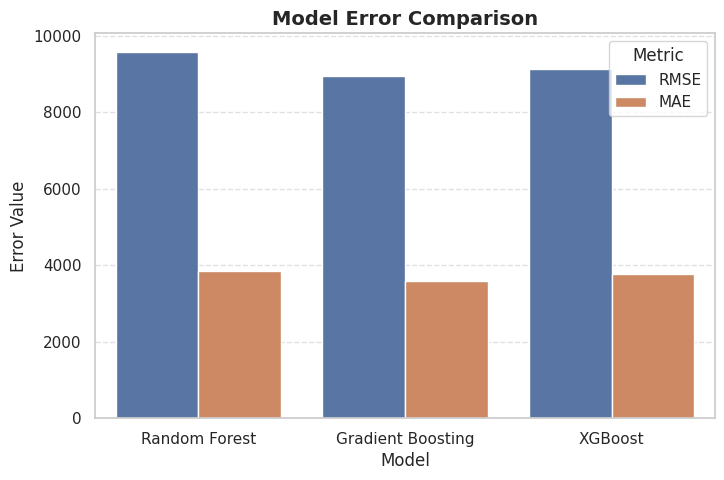

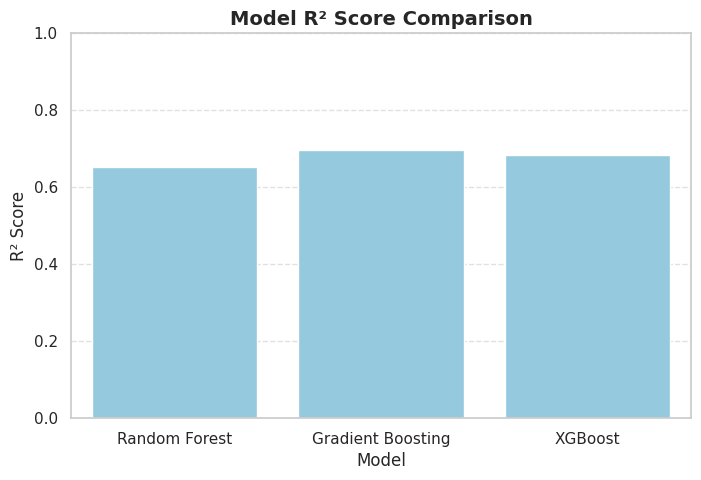

In [43]:
import matplotlib.pyplot as plt
import seaborn as sns

# -------------------------
# RMSE & MAE Comparison
# -------------------------
plt.figure(figsize=(8,5))

results_errors = results.melt(id_vars="Model",
                              value_vars=["RMSE","MAE"],
                              var_name="Metric",
                              value_name="Score")

sns.barplot(data=results_errors, x="Model", y="Score", hue="Metric")

plt.title("Model Error Comparison")
plt.ylabel("Error Value")
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()


# -------------------------
# R2 Comparison
# -------------------------
plt.figure(figsize=(8,5))

sns.barplot(data=results, x="Model", y="R2", color="skyblue")

plt.title("Model R² Score Comparison")
plt.ylabel("R² Score")
plt.ylim(0,1)
plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.show()
